# Dictionary Learning: K-SVD  (Aharon et al., 2006)

* Install: pip install ksvd
* Source:  https://github.com/nel215/ksvd
* Paper:   Aharon, Elad, Bruckstein — "K-SVD: An algorithm for designing overcomplete dictionaries for sparse representation", IEEE TSP 2006.

* Algorithm:
*   Step 1 — Sparse Coding: for each signal y_i, solve
    * min ||y_i - D*x_i||  s.t. ||x_i||_0 <= k  using OMP
*   Step 2 — Dictionary Update: for each atom d_j:
    1. Find all signals that use atom j: omega_j = {i : x_j_i != 0}
    2. Compute residual: E_j = Y[:,omega_j] - sum_{l!=j} d_l * x_l[omega_j]
    3. Apply SVD to E_j -> take 1st left singular vector as new d_j and update the coefficients x_j[omega_j] accordingly
*   Repeat until convergence.

* Key difference from MiniBatch:
    *   MiniBatch updates ALL atoms together using gradient on a mini-batch (approximate).
    *   K-SVD updates ONE atom at a time using exact SVD (optimal for that atom given others).

In [1]:
%load_ext autoreload
%autoreload 2
 
import numpy as np
import os
import matplotlib.pyplot as plt
from ksvd import ApproximateKSVD

from utils import (to_per_channel, plot_dictionary_atoms,
                   plot_reconstruction_error)

## PARAMETERS - same as MiniBatch for fair comparison

In [2]:
N_ATOMS  = 600
SPARSITY = 5

### Load pre-split data from 03a

In [4]:
Y1_tr = np.load('preprocessed_data/EMG_Y1_tr.npy')
Y1_te = np.load('preprocessed_data/EMG_Y1_te.npy')
y1_tr = np.load('preprocessed_data/LABELS_y1_tr.npy')
y1_te = np.load('preprocessed_data/LABELS_y1_te.npy')
Y2_tr = np.load('preprocessed_data/EMG_Y2_tr.npy')
Y2_te = np.load('preprocessed_data/EMG_Y2_te.npy')
y2_tr = np.load('preprocessed_data/LABELS_y2_tr.npy')
y2_te = np.load('preprocessed_data/LABELS_y2_te.npy')
 
Y1ch = to_per_channel(Y1_tr)
Y2ch = to_per_channel(Y2_tr)
 
print(f"DB1 per-channel: {Y1ch.shape}")
print(f"DB2 per-channel: {Y2ch.shape}")
print(f"Overcomplete: {N_ATOMS} > {Y1ch.shape[1]} = {N_ATOMS > Y1ch.shape[1]}")
print(f"Overcomplete: {N_ATOMS} > {Y2ch.shape[1]} = {N_ATOMS > Y2ch.shape[1]}")

DB1 per-channel: (163640, 20)
DB2 per-channel: (120936, 400)
Overcomplete: 600 > 20 = True
Overcomplete: 600 > 400 = True


## TRAIN K-SVD
* ApproximateKSVD uses Batch-OMP for the sparse coding step (faster than
* standard OMP while producing equivalent results for large dictionaries).

In [6]:
def train_ksvd(Y_ch, n_atoms, sparsity, max_iter=50, name=""):
    """
    Trains K-SVD on per-channel windows.
    max_iter=50 is typically enough — K-SVD converges faster per iteration
    than MiniBatch because each atom update is exact (via SVD).
    """
    print(f"\n[K-SVD] Training {name}...")
    print(f"  {Y_ch.shape[0]} samples | {n_atoms} atoms | sparsity={sparsity} | {max_iter} iterations")
    ksvd = ApproximateKSVD(
        n_components=n_atoms,
        max_iter=max_iter,
        tol=1e-6,            # stop if dictionary change < tol
        transform_n_nonzero_coefs=sparsity,
    )
    ksvd.fit(Y_ch)
    D = ksvd.components_   # (n_atoms, samples_per_window)
    print(f"  Done. D shape: {D.shape}")
    return D, ksvd

In [7]:
def plot_ksvd_convergence(ksvd, title=""):
    """
    K-SVD convergence: tracks the change in dictionary between iterations.
    Unlike MiniBatch (which tracks reconstruction cost), K-SVD tracks ||D_new - D_old||.
    A value approaching 0 means the dictionary has stopped changing = converged.
    """
    if hasattr(ksvd, 'error_'):
        errors = ksvd.error_
        plt.figure(figsize=(10, 3))
        plt.plot(errors, color='steelblue', marker='o', ms=4)
        plt.title(f'{title} K-SVD — Dictionary change per iteration')
        plt.xlabel('Iteration'); plt.ylabel('||D_new - D_old||')
        plt.grid(True, ls='--', alpha=0.4); plt.tight_layout(); plt.show()
        print(f"  Final dictionary change: {errors[-1]:.6f}")
        if errors[-1] < 1e-4:
            print("  -> Converged (change < 1e-4)")
        else:
            print("  -> Not fully converged. Consider increasing max_iter.")
    else:
        print("  Convergence history not available for this ksvd version.")

In [ ]:
# --- DB1 ---
D1_ksvd, ksvd1 = train_ksvd(Y1ch, N_ATOMS, SPARSITY, max_iter=50, name="DB1")
plot_ksvd_convergence(ksvd1, title="DB1")


[K-SVD] Training DB1...
  163640 samples | 600 atoms | sparsity=5 | 50 iterations
  Done. D shape: (600, 20)
  Convergence history not available for this ksvd version.


TypeError: plot_dictionary_atoms() got an unexpected keyword argument 'n_show'

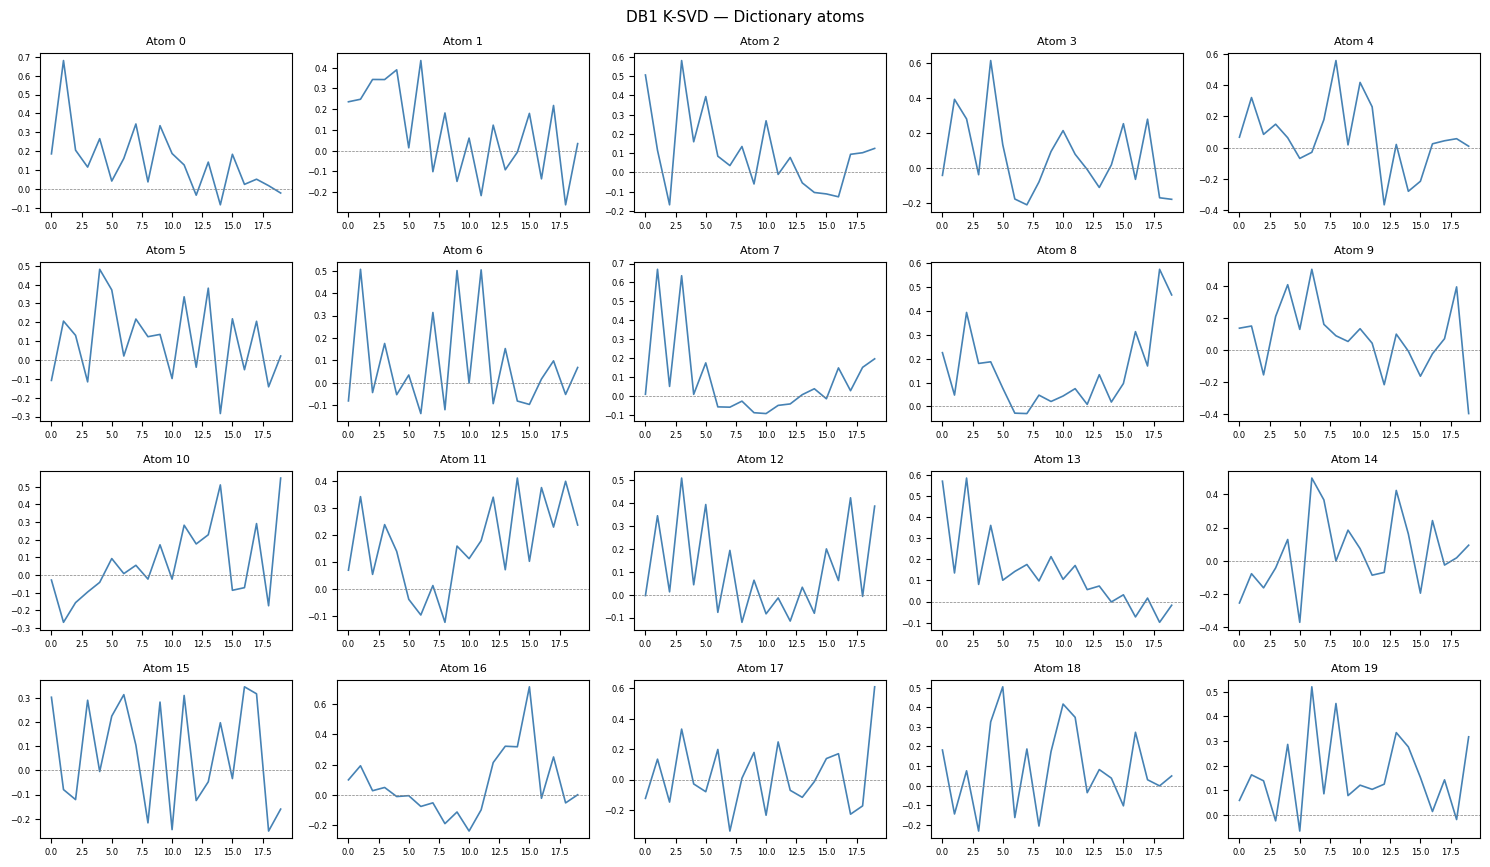

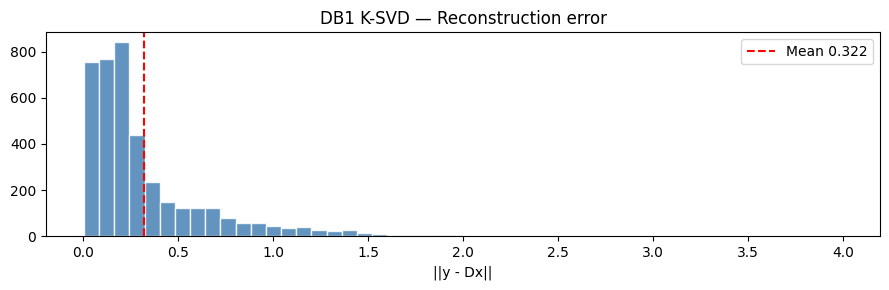

array([0.30242803, 0.25456563, 0.05107535, ..., 0.21100729, 0.01134302,
       0.04892   ], shape=(4000,))

In [9]:
plot_dictionary_atoms(D1_ksvd, n_atoms_to_show=20, title="DB1 K-SVD")
plot_reconstruction_error(Y1_tr, D1_ksvd, SPARSITY, n=400, title="DB1 K-SVD")

In [10]:
# --- DB2 ---
# DB2 is large — K-SVD is slower. Reduce max_iter if needed.
D2_ksvd, ksvd2 = train_ksvd(Y2ch, N_ATOMS, SPARSITY, max_iter=30, name="DB2")
plot_ksvd_convergence(ksvd2, title="DB2")


[K-SVD] Training DB2...
  120936 samples | 600 atoms | sparsity=5 | 30 iterations
  Done. D shape: (600, 400)
  Convergence history not available for this ksvd version.


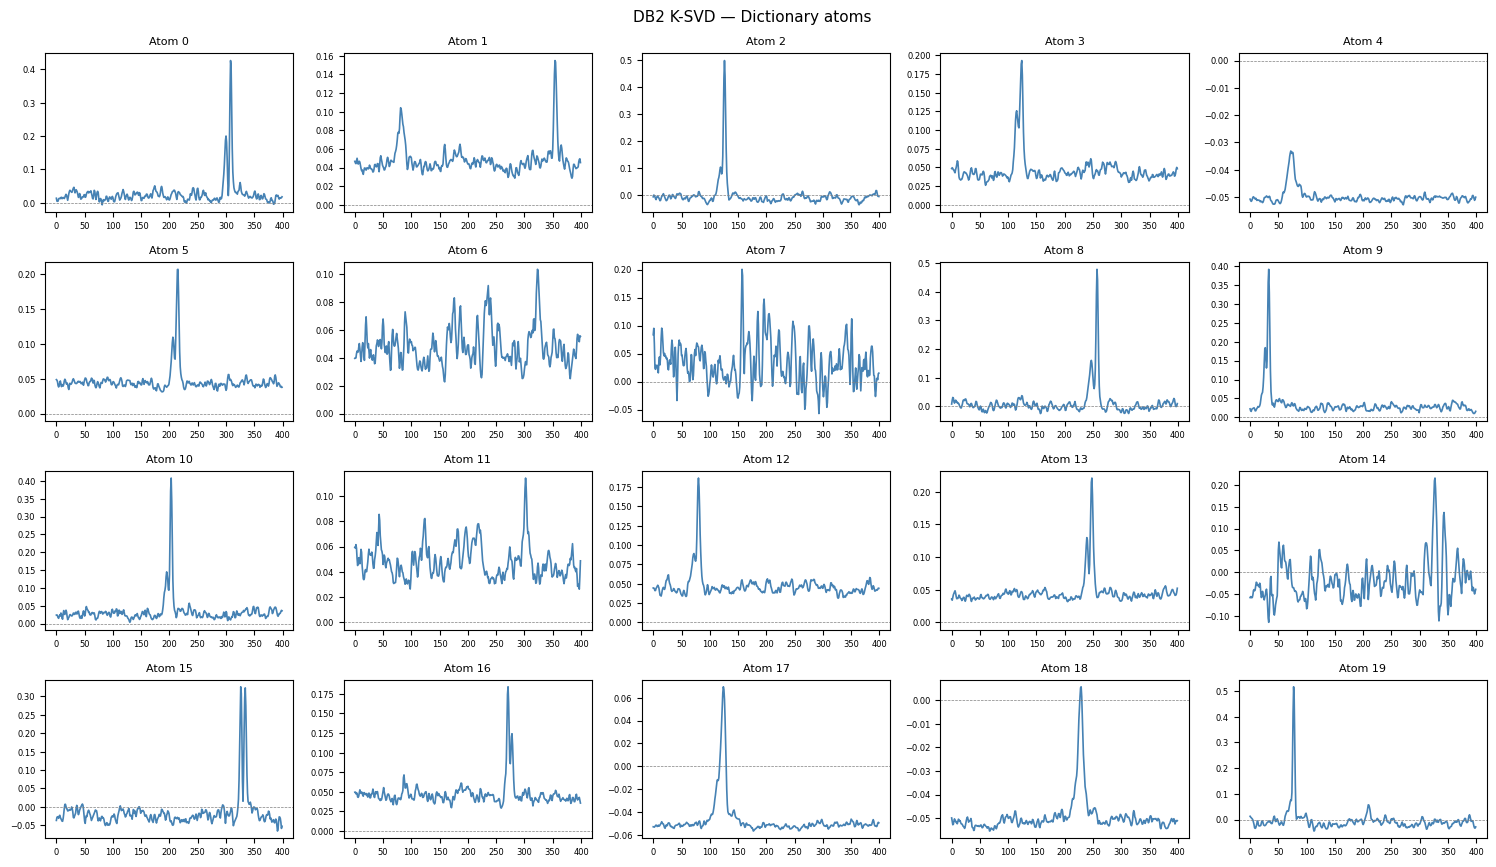

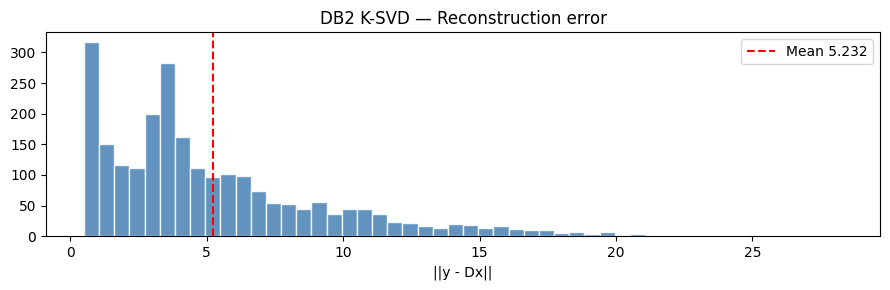

array([9.39880147, 3.02222464, 0.80880399, ..., 1.18823948, 3.45885861,
       6.65200832], shape=(2400,))

In [11]:
plot_dictionary_atoms(D2_ksvd, n_atoms_to_show=20, title="DB2 K-SVD")
plot_reconstruction_error(Y2_tr, D2_ksvd, SPARSITY, n=200, title="DB2 K-SVD")

In [12]:
# --- Save ---
for name, arr in [('D1_ksvd', D1_ksvd), ('D2_ksvd', D2_ksvd)]:
    np.save(f'preprocessed_data/{name}.npy', arr)
print("\nSaved: D1_ksvd, D2_ksvd")


Saved: D1_ksvd, D2_ksvd


## QUALITATIVE COMPARISON — reconstruction error: K-SVD vs MiniBatch


=== Reconstruction error comparison ===


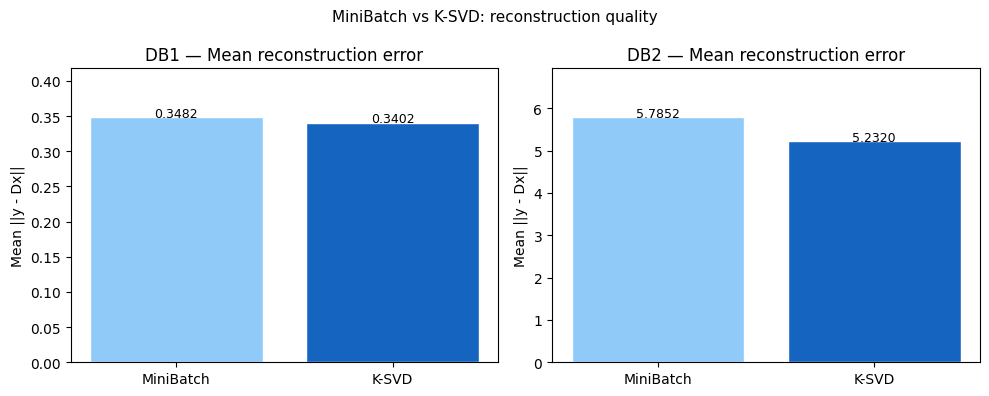

In [13]:
print("\n=== Reconstruction error comparison ===")
from sklearn.decomposition import sparse_encode
 
D1_mb = np.load('preprocessed_data/D1_mb.npy')
D2_mb = np.load('preprocessed_data/D2_mb.npy')
 
def mean_recon_error(Y_3d, D, sparsity, n=200):
    Ych = to_per_channel(Y_3d[:n])
    Xch = sparse_encode(Ych, D, algorithm='omp', n_nonzero_coefs=sparsity, n_jobs=-1)
    return np.linalg.norm(Ych - Xch @ D, axis=1).mean()
 
err1_mb   = mean_recon_error(Y1_tr, D1_mb,   SPARSITY)
err1_ksvd = mean_recon_error(Y1_tr, D1_ksvd, SPARSITY)
err2_mb   = mean_recon_error(Y2_tr, D2_mb,   SPARSITY)
err2_ksvd = mean_recon_error(Y2_tr, D2_ksvd, SPARSITY)
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, vals in [
    (axes[0], 'DB1', [err1_mb, err1_ksvd]),
    (axes[1], 'DB2', [err2_mb, err2_ksvd]),
]:
    bars = ax.bar(['MiniBatch', 'K-SVD'], vals,
                   color=['#90CAF9', '#1565C0'], edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001,
                f'{v:.4f}', ha='center', fontsize=9)
    ax.set_title(f'{label} — Mean reconstruction error')
    ax.set_ylabel('Mean ||y - Dx||')
    ax.set_ylim(0, max(vals)*1.2)
plt.suptitle('MiniBatch vs K-SVD: reconstruction quality', fontsize=11)
plt.tight_layout(); plt.show()

In [14]:
print(f"\nDB1  MiniBatch: {err1_mb:.4f}  |  K-SVD: {err1_ksvd:.4f}")
print(f"DB2  MiniBatch: {err2_mb:.4f}  |  K-SVD: {err2_ksvd:.4f}")
print("\nLower reconstruction error = dictionary explains signals better.")
print("The algorithm with lower error may not always give higher classification accuracy.")
print("Classification notebook (04) will compare both on the same test set.")


DB1  MiniBatch: 0.3482  |  K-SVD: 0.3402
DB2  MiniBatch: 5.7852  |  K-SVD: 5.2320

Lower reconstruction error = dictionary explains signals better.
The algorithm with lower error may not always give higher classification accuracy.
Classification notebook (04) will compare both on the same test set.
